In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
from torch.nn.functional import pad
import os

In [2]:
os.chdir("/u/sebono/conversational_dominance/information_exchange_labelling")
print(os.getcwd())

from perplexity_labelling import compute_p1, compute_p2, compute_p3
from utils import (
    # VISUALIZATION
    rolling_kde_heatmap_with_turns,
    display_turns_colored_by_kde,
    compute_graph_perplexity,
    correlation_heatmap,
    # HELPERS
    compute_dominance_per_spk,
    expand_multiple_ppl_by_token,
    remove_match_prefix_ppl,
    assign_words_to_bins,
    compute_significance,
    display_colored_sentences
)

/u/sebono/conversational_dominance/information_exchange_labelling


[nltk_data] Downloading package punkt to /u/sebono/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /u/sebono/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from transformers import LlamaForCausalLM, LlamaTokenizerFast

import argparse
import pickle
import os
import json
import pandas as pd

#model_id = "unsloth/Meta-Llama-3.1-8B-bnb-4bit"
model_id="gpt2-large"
device = "cuda:1"
perplexity_func = "p1"

if "gpt2" in model_id:
    #model = GPT2LMHeadModel.from_pretrained(model_id).to(device)
    tokenizer = GPT2TokenizerFast.from_pretrained(model_id)
    start_of_sentence=" "
if "Llama" in model_id:
    #model = LlamaForCausalLM.from_pretrained(model_id, device_map="auto")
    tokenizer = LlamaTokenizerFast.from_pretrained(model_id)
    start_of_sentence='<|begin_of_text|>'

In [4]:
import pandas as pd
import re
import numpy as np

multisimo_df_with_annotations = pd.read_csv("/u/sebono/conversational_dominance/data/processed/multisimo/transcript_dominance.csv")
multisimo_df_with_annotations

,file_name,speaker_1_1,speaker_1_2,speaker_1_3,speaker_1_4,speaker_1_5,speaker_2_1,speaker_2_2,speaker_2_3,speaker_2_4,speaker_2_5,speaker_1_dom_score,speaker_2_dom_score,file_content,speaker_1,speaker_2
0,S02,3.0,2.0,2.0,2.0,1.0,4.0,3.0,3.0,4.0,3.0,2.0,3.4,<MOD>: Ok so thanks for coming today. we're go...,P006,P007
1,S03,2.0,2.0,2.0,2.0,2.0,4.0,3.0,3.0,5.0,2.0,2.0,3.4,<MOD> Ok hello we are going to play a quiz. <...,P008,P009
2,S04,2.0,1.0,2.0,4.0,1.0,1.0,1.0,1.0,4.0,1.0,2.0,1.6,"<MOD>: ok Hello, thank you for coming today, w...",P010,P011
3,S05,4.0,4.0,4.0,4.0,3.0,3.0,2.0,3.0,1.0,1.0,3.8,2.0,"<MOD>: Ok hi welcome, thank you for coming tod...",P012,P013
4,S07,4.0,2.0,3.0,4.0,4.0,4.0,2.0,3.0,5.0,3.0,3.4,3.4,"<MOD>: <MOD>: Ok. So welcome, thank you very m...",P016,P017
5,S08,4.0,2.0,3.0,2.0,1.0,3.0,3.0,3.0,3.0,2.0,2.4,2.8,<MOD>: So good evening <SPK2>: Good evening. <...,P018,P019
6,S09,4.0,3.0,3.0,5.0,3.0,4.0,3.0,3.0,5.0,3.0,3.6,3.6,<MOD>: Ok <SPK2>: Yeah so <MOD>: So I would li...,P020,P021
7,S10,3.0,2.0,3.0,4.0,2.0,3.0,2.0,2.0,4.0,2.0,2.8,2.6,<MOD>: Ok. So I would like us to play a quiz. ...,P022,P023
8,S11,5.0,2.0,3.0,3.0,5.0,2.0,1.0,2.0,1.0,1.0,3.6,1.4,"<SPK1>: <MOD>: Right. So, I would like us to p...",P024,P025
9,S13,3.0,1.0,2.0,4.0,2.0,2.0,1.0,2.0,1.0,1.0,2.4,1.4,"<SPK1>: yeah <MOD>: Well hello, thanks very mu...",P028,P029


In [8]:
from glob import glob
import os, re, pickle
import numpy as np
import re
import pandas as pd
from tqdm import tqdm

BASE = "/u/sebono/conversational_dominance/notebooks/information_exchange_labelling/dataset_perplexity_results"


def _pair_distinguishable(spk_dict, alpha=0.05, adjust_p="fdr_bh"):
    """
    Returns True if <SPK1> and <SPK2> are statistically distinguishable
    by any test in compute_significance (after correction if requested).
    """
    # Only consider main speakers that are present
    spks = [s for s in spk_dict.keys() if s.startswith("<SPK")]
    if not ("<SPK1>" in spks and "<SPK2>" in spks):
        return False

    # Your function (must be in scope)
    results_list, results_dict = compute_significance(
        original_ppls_p_spk=spk_dict,
        spk_tokens=["<SPK1>", "<SPK2>"],
        alternative_mw="two-sided",
        equal_var_ttest=False,
        adjust_p=adjust_p
    )

    # Prefer adjusted p if present; otherwise raw p
    best_p = 1.0
    for row in results_list:
        if (row.get("spk_i"), row.get("spk_j")) in [("<SPK1>", "<SPK2>"), ("<SPK2>", "<SPK1>")]:
            p = row.get("p_value_adj", row.get("p_value"))
            if p is not None and not np.isnan(p):
                best_p = min(best_p, p)
    return best_p < alpha

def compute_dominance(dataset, model, ppls, base=BASE, agg=np.nanmean):
    out = {}
    rows = []

    for idx, name in enumerate(list(multisimo_df_with_annotations["file_name"])):
        el = multisimo_df_with_annotations[multisimo_df_with_annotations['file_name']==name]["file_content"]
        dialog = multisimo_df_with_annotations[multisimo_df_with_annotations['file_name']==name]["file_content"][list(el.keys())[0]]

        pattern = r'<(?:SPK[0-9]|MOD)>'
        dialog_lines = re.sub(r"[\[\(].*?[\]\)]", "", dialog).replace("<", "\n<").split("\n")[1:]
        matches = [f"{match}" for match in re.findall(pattern, f"{start_of_sentence}".join(dialog_lines))]
        token_list = [tokenizer(token, return_tensors="pt").input_ids[0] for token in dialog_lines]
        encodings = tokenizer(f"{start_of_sentence}".join(dialog_lines), return_tensors="pt")
        assert np.cumsum([len(token) for token in token_list])[-1] == encodings.input_ids[0].shape
        assert len(matches) == len(dialog_lines)

        all_data = pd.DataFrame({})
        for p_name in ['p1','p2','p3']:
            file_name_sample = f'/u/sebono/conversational_dominance/notebooks/information_exchange_labelling/dataset_perplexity_results/multisimo_{p_name}_{model}/dominance_scores_{name}.pkl'
            with open(file_name_sample, 'rb') as f:
                all_data[f"{p_name}"] = pickle.load(f)[name]

        filtered_tokens_p1, filtered_ppl_p1, filtered_encodings_p1, filtered_matches_p1 = remove_match_prefix_ppl(token_list, all_data['p1'], matches, tokenizer, min_len=0)
        assert np.cumsum([len(token) for token in filtered_tokens_p1])[-1], len(filtered_ppl)

        filtered_tokens_p2, filtered_ppl_p2, filtered_encodings_p2, filtered_matches_p2 = remove_match_prefix_ppl(token_list, all_data['p2'], matches, tokenizer, min_len=0)
        assert np.cumsum([len(token) for token in filtered_tokens_p2])[-1], len(filtered_ppl)

        filtered_tokens_p3, filtered_ppl_p3, filtered_encodings_p3, filtered_matches_p3 = remove_match_prefix_ppl(token_list, all_data['p3'], matches, tokenizer, min_len=0)
        assert np.cumsum([len(token) for token in filtered_tokens_p3])[-1], len(filtered_ppl)

        assert len(filtered_tokens_p3) == len(token_list)
        assert len(filtered_tokens_p1) == len(filtered_tokens_p2)
        assert len(filtered_tokens_p1) == len(filtered_tokens_p3)
        assert filtered_encodings_p1 == filtered_encodings_p2
        assert filtered_encodings_p1 == filtered_encodings_p3
        filtered_encodings = filtered_encodings_p1

        all_data = pd.DataFrame({"p1":filtered_ppl_p1,"p2":filtered_ppl_p2, "p3":filtered_ppl_p3})
        all_data.bfill(inplace=True)

        baselined_ppls_p1_spk = compute_dominance_per_spk(filtered_ppl_p1, filtered_tokens_p1, filtered_matches_p1, tokenizer)
        baselined_ppls_p2_spk = compute_dominance_per_spk(filtered_ppl_p2, filtered_tokens_p2, filtered_matches_p2, tokenizer)
        baselined_ppls_p3_spk = compute_dominance_per_spk(filtered_ppl_p3, filtered_tokens_p3, filtered_matches_p3, tokenizer)

        out[name] = {}
        out[name]['p1'] = dict(zip(baselined_ppls_p1_spk.keys(), [np.mean(baselined_ppls_p1_spk[key]) for key in baselined_ppls_p1_spk.keys()]))
        out[name]['p2'] = dict(zip(baselined_ppls_p2_spk.keys(), [np.mean(baselined_ppls_p2_spk[key]) for key in baselined_ppls_p2_spk.keys()]))
        out[name]['p3'] = dict(zip(baselined_ppls_p3_spk.keys(), [np.mean(baselined_ppls_p3_spk[key]) for key in baselined_ppls_p3_spk.keys()]))

        # --- NEW: gate by significance; if not distinguishable, set SPK1/SPK2 to NaN for that ppl ---
        for p_name, spk_dict_full in [('p1', baselined_ppls_p1_spk),
                                      ('p2', baselined_ppls_p2_spk),
                                      ('p3', baselined_ppls_p3_spk)]:
            if not _pair_distinguishable(spk_dict_full, alpha=0.05, adjust_p="fdr_bh"):
                # Replace only SPK1/SPK2 with NaN (keep MOD or others as-is)
                if "<SPK1>" in out[name][p_name]:
                    out[name][p_name]["<SPK1>"] = np.nan
                if "<SPK2>" in out[name][p_name]:
                    out[name][p_name]["<SPK2>"] = np.nan

        # Collect tidy rows
        for ppl_key in ('p1','p2','p3'):
            for spk, val in out[name][ppl_key].items():
                rows.append((name, ppl_key, spk, float(val) if val is not None else np.nan))

    # build tidy rows as before
    df = pd.DataFrame(rows, columns=['file_name','ppl','speaker','mean_dominance'])

    # Pivot to columns = (speaker, ppl)
    wide = df.pivot_table(index='file_name',
                          columns=['speaker','ppl'],
                          values='mean_dominance',
                          aggfunc='mean')

    def spk_key(s):
        m = re.match(r'<SPK(\d+)>', s or '')
        return (1, int(m.group(1))) if m else (2, 0)

    spk_levels = list(wide.columns.levels[0])
    ppl_levels = list(wide.columns.levels[1])
    spk_levels = sorted(spk_levels, key=spk_key)
    desired_ppls = [p for p in ['p1','p2','p3'] if p in ppl_levels]

    wide = wide.reindex(pd.MultiIndex.from_product([spk_levels, desired_ppls]), axis=1)

    # Flatten (speaker, ppl) -> "<SPK#>_p#"
    wide.columns = [f"{spk}_{ppl}" for spk, ppl in wide.columns]
    wide = wide.reset_index()
    return wide, out

In [9]:
DATASET = "multisimo"      # e.g. "multisimo"
MODEL = model_id           # e.g. "gpt2-large"
PPLS = ["p1", "p2", "p3"]  # which folders to scan

data, out_data = compute_dominance(DATASET, MODEL, PPLS)

In [10]:
data

,file_name,<SPK1>_p1,<SPK1>_p2,<SPK1>_p3,<SPK2>_p1,<SPK2>_p2,<SPK2>_p3,<MOD>_p1,<MOD>_p2,<MOD>_p3
0,S02,NaN,NaN,3.049660,NaN,NaN,2.737478,4.022203,3.031982,2.723054
1,S03,3.962520,1.937148,NaN,4.341622,2.119659,NaN,3.799996,2.982193,2.934884
2,S04,NaN,2.073970,3.537811,NaN,2.092015,2.949137,3.546387,2.785428,3.015136
3,S05,4.188193,2.072725,2.806363,3.788684,2.318109,2.983645,3.639212,2.874101,2.862360
4,S07,4.025574,1.903269,NaN,3.702209,1.735428,NaN,4.036035,2.865421,2.773285
5,S08,NaN,NaN,NaN,NaN,NaN,NaN,4.136449,3.077470,2.740312
6,S09,NaN,NaN,NaN,NaN,NaN,NaN,3.746910,2.688615,2.763713
7,S10,NaN,2.096486,3.595249,NaN,2.184143,3.055701,3.617964,2.882619,3.383688
8,S11,4.319915,NaN,NaN,3.598561,NaN,NaN,3.696608,2.850556,2.653987
9,S13,NaN,1.777659,NaN,NaN,2.044862,NaN,3.849274,2.803640,2.732875


In [11]:
cols = ["file_name", "speaker_1_dom_score", "speaker_2_dom_score", 
        #"speaker_1_1", "speaker_1_2", "speaker_1_3", "speaker_1_4", "speaker_1_5", "speaker_2_1", "speaker_2_2", "speaker_2_3", "speaker_2_4", "speaker_2_5", 
        "<SPK1>_p1", "<SPK2>_p1", "<SPK1>_p2", "<SPK2>_p2", "<SPK1>_p3", "<SPK2>_p3"]
comparison_ppl_dom_data = data.merge(multisimo_df_with_annotations, on="file_name")[cols]
comparison_ppl_dom_data

,file_name,speaker_1_dom_score,speaker_2_dom_score,<SPK1>_p1,<SPK2>_p1,<SPK1>_p2,<SPK2>_p2,<SPK1>_p3,<SPK2>_p3
0,S02,2.0,3.4,NaN,NaN,NaN,NaN,3.049660,2.737478
1,S03,2.0,3.4,3.962520,4.341622,1.937148,2.119659,NaN,NaN
2,S04,2.0,1.6,NaN,NaN,2.073970,2.092015,3.537811,2.949137
3,S05,3.8,2.0,4.188193,3.788684,2.072725,2.318109,2.806363,2.983645
4,S07,3.4,3.4,4.025574,3.702209,1.903269,1.735428,NaN,NaN
5,S08,2.4,2.8,NaN,NaN,NaN,NaN,NaN,NaN
6,S09,3.6,3.6,NaN,NaN,NaN,NaN,NaN,NaN
7,S10,2.8,2.6,NaN,NaN,2.096486,2.184143,3.595249,3.055701
8,S11,3.6,1.4,4.319915,3.598561,NaN,NaN,NaN,NaN
9,S13,2.4,1.4,NaN,NaN,1.777659,2.044862,NaN,NaN


In [12]:
col_1 = cols[1:3]
col_2 = cols[4:]

In [13]:
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_2,comparison_ppl_dom_data)

In [14]:
fig_corr

In [15]:
fig_p

### Analysis

In [16]:
file_name="S11"
dialog = multisimo_df_with_annotations[multisimo_df_with_annotations['file_name']==file_name]["file_content"][8]

In [17]:
import re 
pattern = r'<(?:SPK[0-9]|MOD)>'
dialog_lines = re.sub(r"[\[\(].*?[\]\)]", "", dialog).replace("<", "\n<").split("\n")[1:]
matches = [f"{match}" for match in re.findall(pattern, f"{start_of_sentence}".join(dialog_lines))]
token_list = [tokenizer(token, return_tensors="pt").input_ids[0] for token in dialog_lines]
encodings = tokenizer(f"{start_of_sentence}".join(dialog_lines), return_tensors="pt")
assert np.cumsum([len(token) for token in token_list])[-1] == encodings.input_ids[0].shape
assert len(matches) == len(dialog_lines)

In [18]:
all_data = pd.DataFrame({})
for p_name in ['p1','p2','p3']:
    file_name_sample = f'/u/sebono/conversational_dominance/notebooks/information_exchange_labelling/dataset_perplexity_results/multisimo_{p_name}_{model_id}/dominance_scores_{file_name}.pkl'
    with open(file_name_sample, 'rb') as f:
        all_data[f"{p_name}"] = pickle.load(f)[file_name]

In [19]:
all_data.bfill(inplace=True)

filtered_tokens_p1, filtered_ppl_p1, filtered_encodings_p1, filtered_matches_p1 = remove_match_prefix_ppl(token_list, all_data['p1'], matches, tokenizer, min_len=0)
assert np.cumsum([len(token) for token in filtered_tokens_p1])[-1], len(filtered_ppl)

filtered_tokens_p2, filtered_ppl_p2, filtered_encodings_p2, filtered_matches_p2 = remove_match_prefix_ppl(token_list, all_data['p2'], matches, tokenizer, min_len=0)
assert np.cumsum([len(token) for token in filtered_tokens_p2])[-1], len(filtered_ppl)

filtered_tokens_p3, filtered_ppl_p3, filtered_encodings_p3, filtered_matches_p3 = remove_match_prefix_ppl(token_list, all_data['p3'], matches, tokenizer, min_len=0)
assert np.cumsum([len(token) for token in filtered_tokens_p3])[-1], len(filtered_ppl)

assert len(filtered_tokens_p3) == len(token_list)
assert len(filtered_tokens_p1) == len(filtered_tokens_p2)
assert len(filtered_tokens_p1) == len(filtered_tokens_p3)
assert filtered_encodings_p1 == filtered_encodings_p2
assert filtered_encodings_p1 == filtered_encodings_p3
filtered_encodings = filtered_encodings_p1

all_data_filtered = pd.DataFrame({"p1":filtered_ppl_p1,"p2":filtered_ppl_p2, "p3":filtered_ppl_p3 })

In [32]:
last=50
end = np.cumsum([len(l) for l in filtered_tokens_p1[:last]])[-1]

/u/sebono/conversational_dominance/information_exchange_labelling/utils.py:550: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



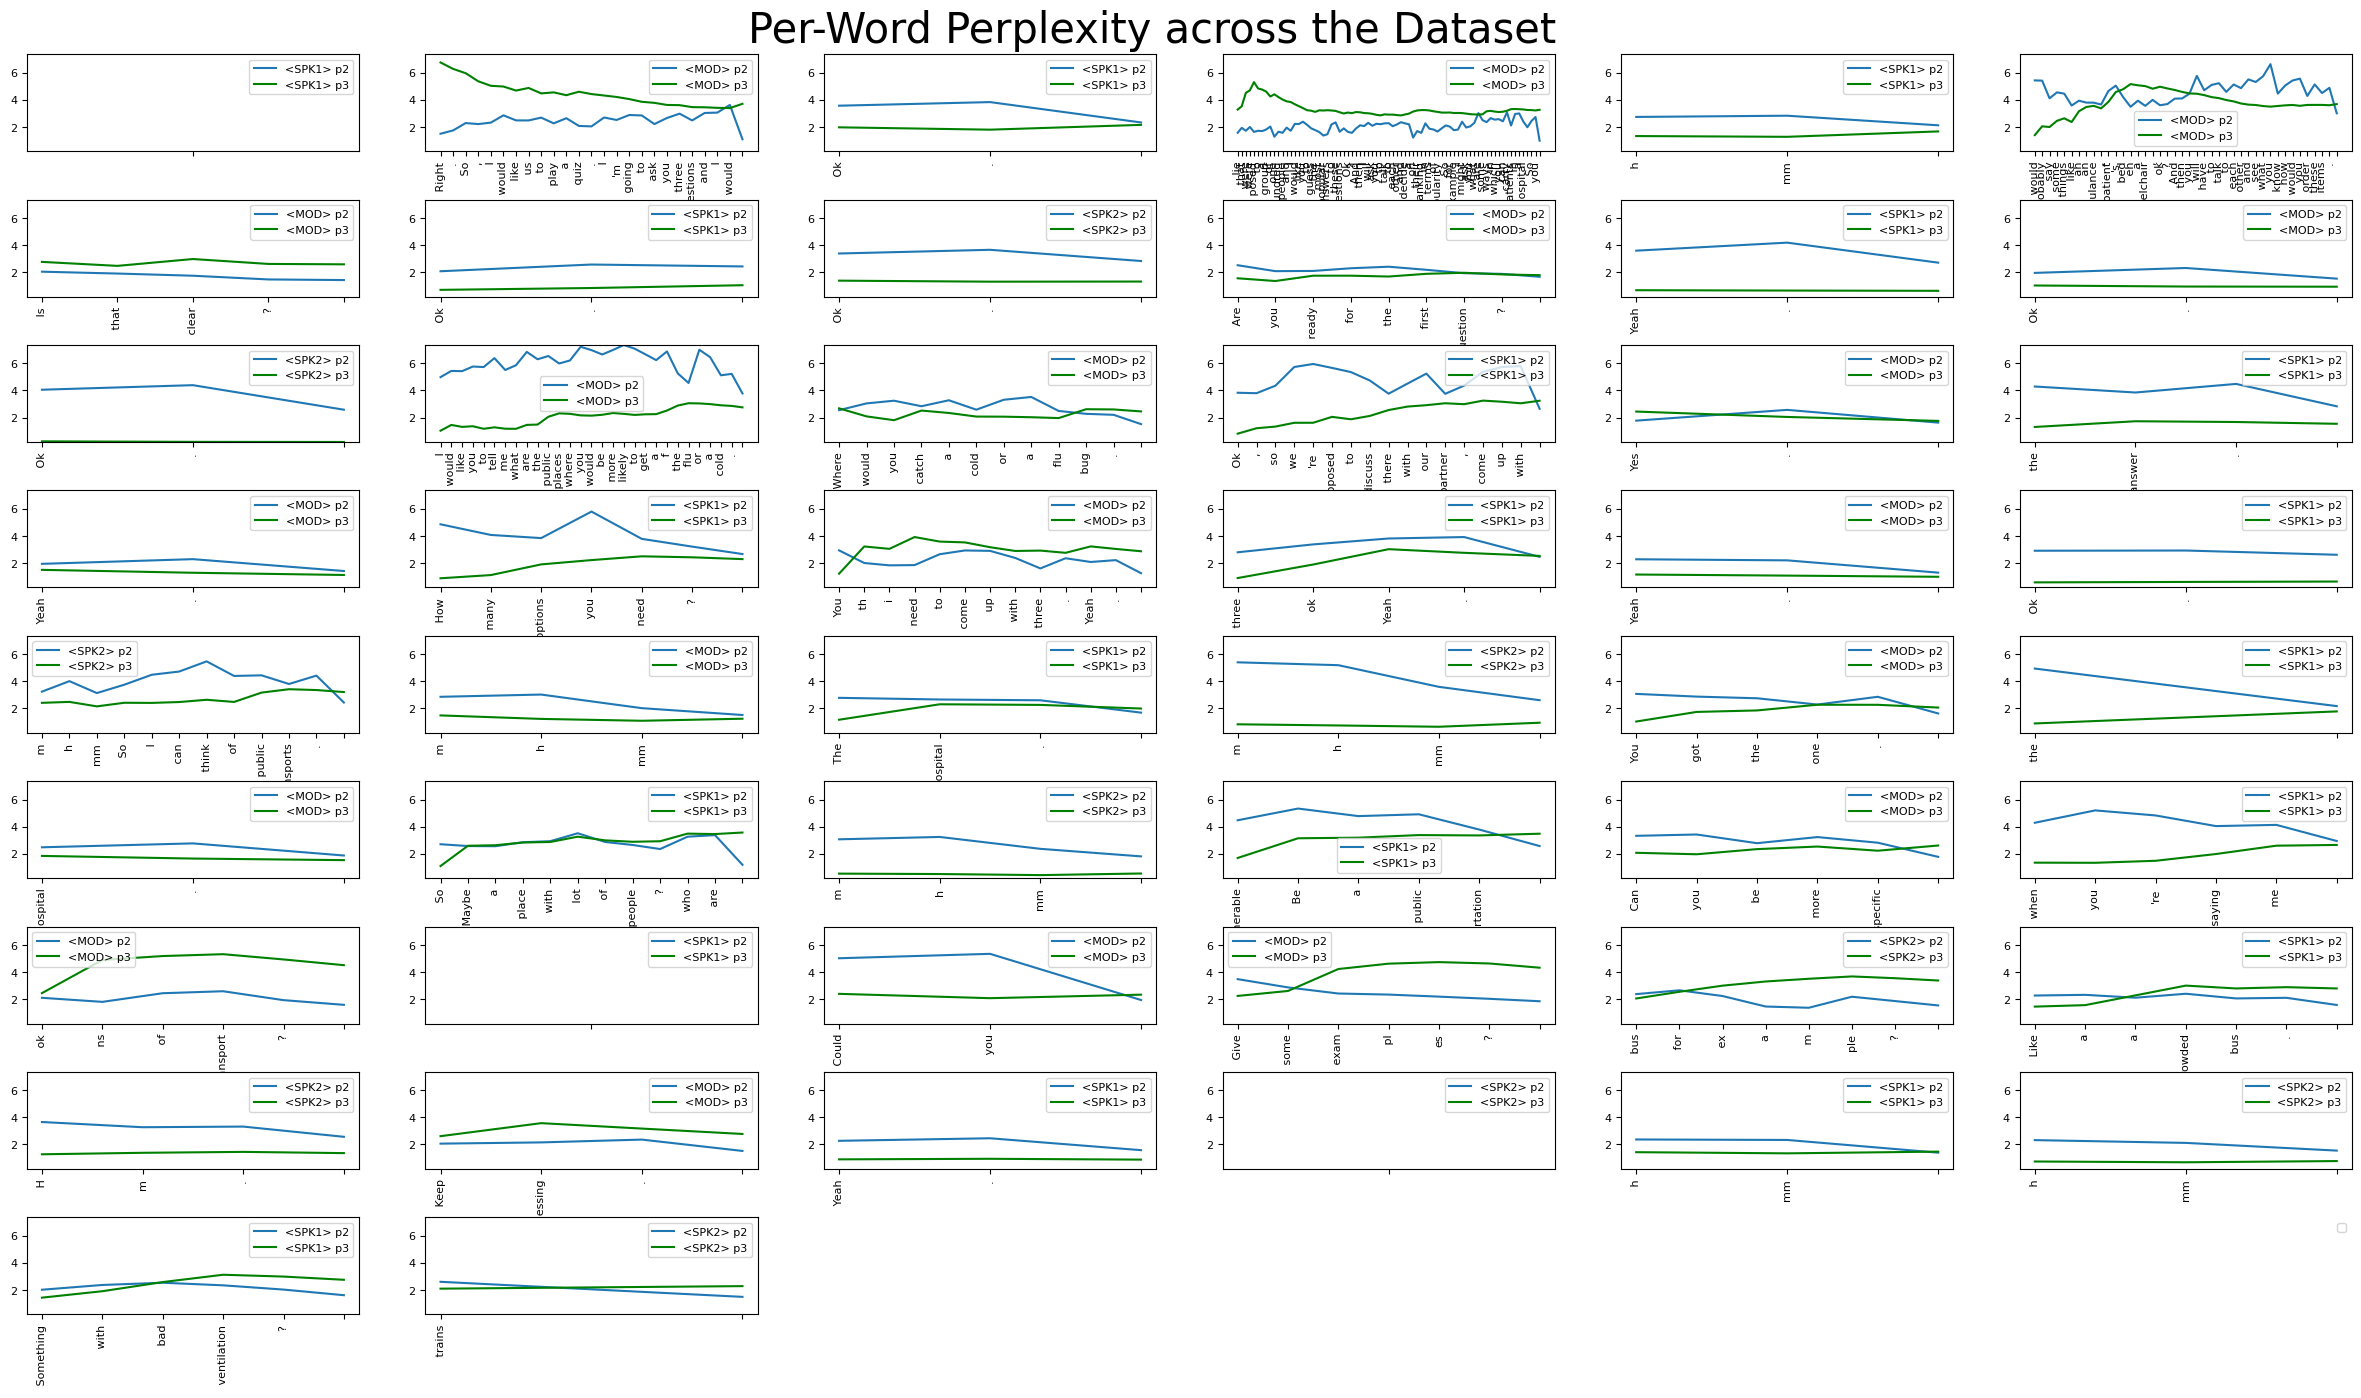

In [42]:
compute_graph_perplexity(tokenizer, filtered_tokens_p2[:last], filtered_ppl_p3[:end], filtered_ppl_p2[:end], filtered_matches_p2[:last], {"p1":"p2","p2":"p3"}, answers=None)

In [233]:
[tokenizer.decode(token, skip_special_tokens=True) for token in filtered_tokens_p3]

[' ',
 " Right. So, I would like us to play a quiz. I'm going to ask you three questions and I would ",
 ' Ok. ',
 ' lie that were were posed to a group of one hundred people and I would like you to guess the most popular answers to these questions. Ok? And then I will ask you to talk to each other and decide a on their ranking in terms of popularity. So for example I might ask you what are some ways in which you can carry patients in a hospital. So you ',
 ' hmm ',
 " would probably say some things like ah an ambulance, patient's bed eh a wheelchair, ok? And then you will have to talk to each other and see what you know how would you order these items. ",
 ' Is that clear? ',
 ' Ok. ',
 ' Ok. ',
 ' Are you ready for the first question? ',
 ' Yeah. ',
 ' Ok. ',
 ' Ok. ',
 ' I would like you to tell me what are the public places where you would be more likely to get a f the flu or a cold. ',
 ' Where would you catch a cold or a flu bug. ',
 " Ok, so we're supposed to discuss there with 

In [37]:
ppls_p1_spk = compute_dominance_per_spk(filtered_ppl_p1, filtered_tokens_p1, filtered_matches_p1, tokenizer)
ppls_p2_spk = compute_dominance_per_spk(filtered_ppl_p2, filtered_tokens_p2, filtered_matches_p2, tokenizer)
ppls_p3_spk = compute_dominance_per_spk(filtered_ppl_p3, filtered_tokens_p3, filtered_matches_p3, tokenizer)

In [50]:
np.mean(ppls_p3_spk['<SPK1>']), np.mean(ppls_p3_spk['<SPK2>'])

(3.3683391751502527, 3.268601420257665)

In [46]:
np.mean(ppls_p1_spk['<SPK1>']) > np.mean(ppls_p1_spk['<SPK2>']), np.mean(ppls_p2_spk['<SPK1>']) > np.mean(ppls_p2_spk['<SPK2>']), np.mean(ppls_p3_spk['<SPK1>']) < np.mean(ppls_p3_spk['<SPK2>'])

(True, True, False)

In [56]:
rows, nested = compute_significance(ppls_p2_spk, ['<SPK1>', '<SPK2>'], adjust_p="fdr_bh")

# If you want a DataFrame:
import pandas as pd
df = pd.DataFrame(rows).sort_values(["test","p_value"])
df

,test,spk_i,spk_j,n_i,n_j,statistic,p_value,p_value_adj
0,KS,<SPK1>,<SPK2>,689,395,0.067895,0.186448,0.186448
1,Mann-Whitney U,<SPK1>,<SPK2>,689,395,138031.000000,0.693800,0.693800
2,T-test,<SPK1>,<SPK2>,689,395,0.853601,0.393555,0.393555


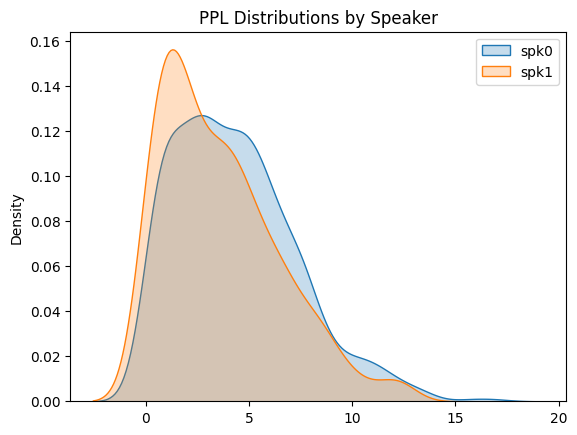

In [241]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(ppls_p1_spk[f"<SPK1>"], label="spk0", fill=True)
sns.kdeplot(ppls_p1_spk[f"<SPK2>"], label="spk1", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

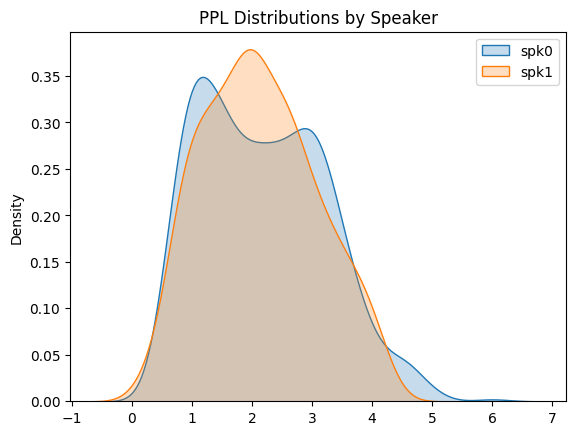

In [242]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(ppls_p2_spk[f"<SPK1>"], label="spk0", fill=True)
sns.kdeplot(ppls_p2_spk[f"<SPK2>"], label="spk1", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

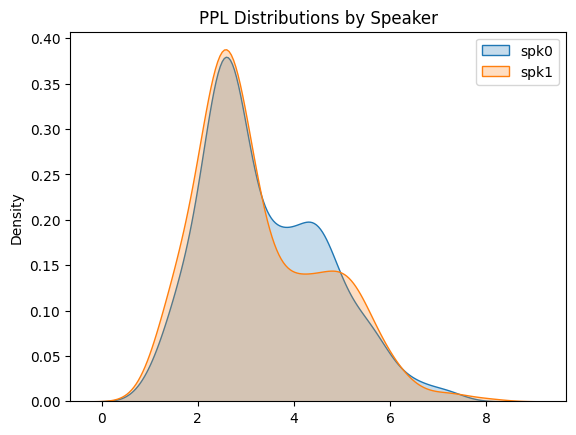

In [243]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(ppls_p3_spk[f"<SPK1>"], label="spk0", fill=True)
sns.kdeplot(ppls_p3_spk[f"<SPK2>"], label="spk1", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

In [244]:
# BEFORE
col_1 = ["p1","p2","p3"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data_filtered)

In [245]:
fig_corr

In [246]:
fig_p

### Per-turn Analysis

In [247]:
per_turn_ppl = pd.DataFrame({"tokens": filtered_tokens_p1})

In [248]:
from itertools import count

# Start from offset
start_index = 0
counter = count(start=start_index)

# Function to assign token indices
def assign_indices(token_list):
    return [next(counter) for _ in token_list]

per_turn_ppl["ppl"] = per_turn_ppl["tokens"].apply(assign_indices)

In [249]:
per_turn_ppl["ppl"].iloc[-1][-1], len(filtered_ppl_p3)

(1997, 1998)

In [250]:
np.mean(filtered_ppl_p3[0:8])

2.6032618582248688

In [251]:
per_turn_ppl

,tokens,ppl
0,[tensor(220)],[0]
1,"[tensor(6498), tensor(13), tensor(1406), tenso...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
2,"[tensor(6762), tensor(13), tensor(220)]","[26, 27, 28]"
3,"[tensor(6486), tensor(326), tensor(547), tenso...","[29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 4..."
4,"[tensor(289), tensor(3020), tensor(220)]","[104, 105, 106]"
...,...,...
319,"[tensor(1406), tensor(475), tensor(3763), tens...","[1956, 1957, 1958, 1959, 1960, 1961, 1962, 196..."
320,"[tensor(6762), tensor(13), tensor(220)]","[1980, 1981, 1982]"
321,"[tensor(5875), tensor(345), tensor(845), tenso...","[1983, 1984, 1985, 1986, 1987, 1988]"
322,"[tensor(6762), tensor(13), tensor(6952), tenso...","[1989, 1990, 1991, 1992, 1993, 1994]"


In [252]:
per_turn_ppl["speaker"] = filtered_matches_p1

In [253]:
per_turn_ppl["p1"] = per_turn_ppl["ppl"].apply(
    lambda idxs: np.asarray(filtered_ppl_p1)[idxs].mean(axis=0) if len(idxs) > 0 else np.nan
)
per_turn_ppl["p2"] = per_turn_ppl["ppl"].apply(
    lambda idxs: np.asarray(filtered_ppl_p2)[idxs].mean(axis=0) if len(idxs) > 0 else np.nan
)
per_turn_ppl["p3"] = per_turn_ppl["ppl"].apply(
    lambda idxs: np.asarray(filtered_ppl_p3)[idxs].mean(axis=0) if len(idxs) > 0 else np.nan
)

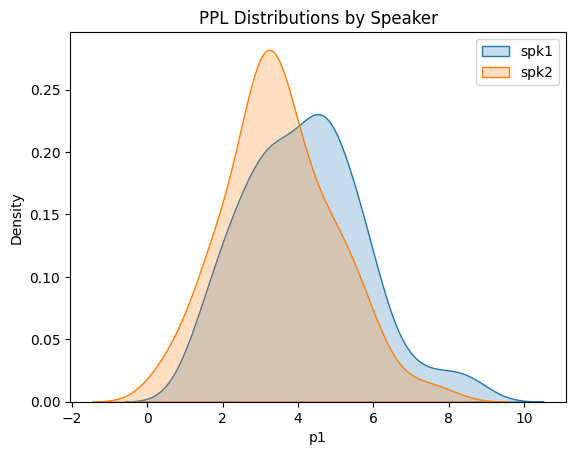

In [254]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p1'], label="spk1", fill=True)
sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p1'], label="spk2", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

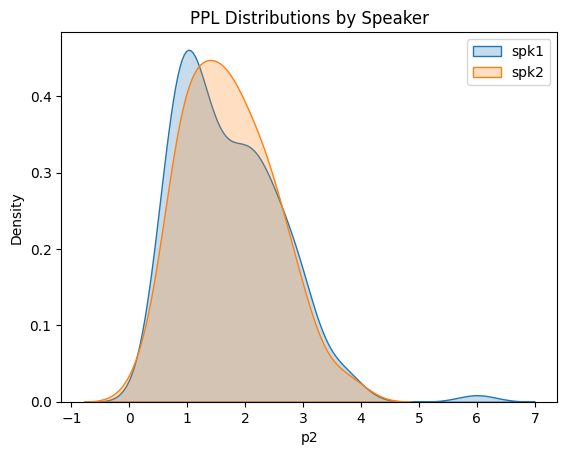

In [255]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p2'], label="spk1", fill=True)
sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p2'], label="spk2", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

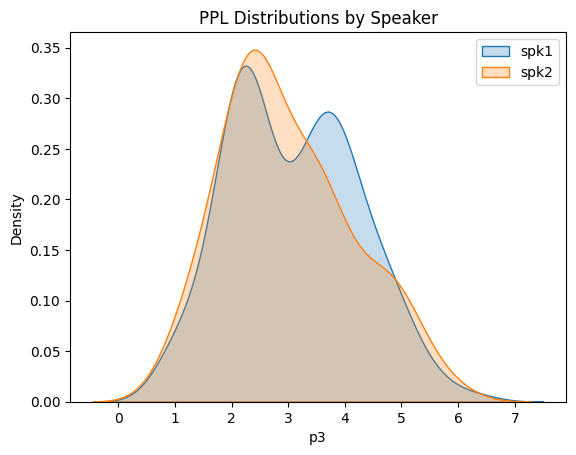

In [256]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p3'], label="spk1", fill=True)
sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p3'], label="spk2", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

In [257]:
ppls_p1_spk = dict({"<SPK1>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p1'], "<SPK2>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p1'], "<MOD>":per_turn_ppl[per_turn_ppl["speaker"]=="<MOD>"]['p1']})
ppls_p2_spk = dict({"<SPK1>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p2'], "<SPK2>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p2'], "<MOD>":per_turn_ppl[per_turn_ppl["speaker"]=="<MOD>"]['p2']})
ppls_p3_spk = dict({"<SPK1>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p3'], "<SPK2>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p3'], "<MOD>":per_turn_ppl[per_turn_ppl["speaker"]=="<MOD>"]['p3']})

In [258]:
rows, nested = compute_significance(ppls_p1_spk, list(np.unique(filtered_matches_p1)), adjust_p="fdr_bh")

# If you want a DataFrame:
import pandas as pd
df = pd.DataFrame(rows).sort_values(["test","p_value"])
df

,test,spk_i,spk_j,n_i,n_j,statistic,p_value,p_value_adj
0,KS,<MOD>,<SPK1>,114,141,0.231243,0.001869,0.005606
2,KS,<SPK1>,<SPK2>,141,69,0.227567,0.013414,0.020121
1,KS,<MOD>,<SPK2>,114,69,0.131198,0.406752,0.406752
5,Mann-Whitney U,<SPK1>,<SPK2>,141,69,5988.000000,0.006624,0.018492
3,Mann-Whitney U,<MOD>,<SPK1>,114,141,6571.000000,0.012328,0.018492
4,Mann-Whitney U,<MOD>,<SPK2>,114,69,4253.000000,0.357586,0.357586
8,T-test,<SPK1>,<SPK2>,141,69,2.938353,0.003833,0.009636
6,T-test,<MOD>,<SPK1>,114,141,-2.748249,0.006424,0.009636
7,T-test,<MOD>,<SPK2>,114,69,0.776695,0.438804,0.438804


In [259]:
rows, nested = compute_significance(ppls_p2_spk, list(np.unique(filtered_matches_p1)), adjust_p="fdr_bh")

# If you want a DataFrame:
import pandas as pd
df = pd.DataFrame(rows).sort_values(["test","p_value"])
df.head()

,test,spk_i,spk_j,n_i,n_j,statistic,p_value,p_value_adj
0,KS,<MOD>,<SPK1>,114,141,0.382419,9.337475e-09,2.801243e-08
1,KS,<MOD>,<SPK2>,114,69,0.389397,2.332716e-06,3.499074e-06
2,KS,<SPK1>,<SPK2>,141,69,0.093432,7.687436e-01,7.687436e-01
3,Mann-Whitney U,<MOD>,<SPK1>,114,141,11961.000000,2.082543e-11,6.247629e-11
4,Mann-Whitney U,<MOD>,<SPK2>,114,69,5881.000000,2.050722e-08,3.076084e-08


In [260]:
rows, nested = compute_significance(ppls_p3_spk, list(np.unique(filtered_matches_p1)), adjust_p="fdr_bh")

# If you want a DataFrame:
import pandas as pd
df = pd.DataFrame(rows).sort_values(["test","p_value"])
df

,test,spk_i,spk_j,n_i,n_j,statistic,p_value,p_value_adj
0,KS,<MOD>,<SPK1>,114,141,0.454647,2.664442e-12,7.993326e-12
1,KS,<MOD>,<SPK2>,114,69,0.387490,2.737854e-06,4.106781e-06
2,KS,<SPK1>,<SPK2>,141,69,0.108850,5.953495e-01,5.953495e-01
3,Mann-Whitney U,<MOD>,<SPK1>,114,141,5039.000000,3.074918e-07,9.224754e-07
4,Mann-Whitney U,<MOD>,<SPK2>,114,69,2612.000000,1.433754e-04,2.150631e-04
5,Mann-Whitney U,<SPK1>,<SPK2>,141,69,5113.000000,5.487679e-01,5.487679e-01
6,T-test,<MOD>,<SPK1>,114,141,-6.250974,1.873141e-09,5.619423e-09
7,T-test,<MOD>,<SPK2>,114,69,-4.135656,7.407850e-05,1.111177e-04
8,T-test,<SPK1>,<SPK2>,141,69,0.564846,5.731204e-01,5.731204e-01


In [261]:
per_turn_ppl["dialog"] = per_turn_ppl["tokens"].map(lambda x: " ".join([tokenizer.decode(token, skip_special_tokens=True) for token in x]))

In [262]:
per_turn_ppl.iloc[15:]

,tokens,ppl,speaker,p1,p2,p3,dialog
15,"[tensor(6762), tensor(11), tensor(523), tensor...","[219, 220, 221, 222, 223, 224, 225, 226, 227, ...",<SPK1>,4.139245,2.333025,4.740775,"Ok , so we 're supposed to discuss ther..."
16,"[tensor(3363), tensor(13), tensor(220)]","[236, 237, 238]",<MOD>,1.663433,2.080241,1.988601,Yes .
17,"[tensor(262), tensor(3280), tensor(13), tensor...","[239, 240, 241, 242]",<SPK1>,3.250558,1.561076,3.863491,the answer .
18,"[tensor(9425), tensor(13), tensor(220)]","[243, 244, 245]",<MOD>,2.011049,1.292235,1.872397,Yeah .
19,"[tensor(1374), tensor(867), tensor(3689), tens...","[246, 247, 248, 249, 250, 251, 252]",<SPK1>,3.827379,1.894809,4.025919,How many options you need ?
...,...,...,...,...,...,...,...
319,"[tensor(1406), tensor(475), tensor(3763), tens...","[1956, 1957, 1958, 1959, 1960, 1961, 1962, 196...",<MOD>,3.322980,3.413648,2.506734,So but yes I mean you did very well ...
320,"[tensor(6762), tensor(13), tensor(220)]","[1980, 1981, 1982]",<SPK1>,1.801531,0.784592,3.777771,Ok .
321,"[tensor(5875), tensor(345), tensor(845), tenso...","[1983, 1984, 1985, 1986, 1987, 1988]",<MOD>,1.675423,1.379770,3.532764,thank you very much .
322,"[tensor(6762), tensor(13), tensor(6952), tenso...","[1989, 1990, 1991, 1992, 1993, 1994]",<SPK2>,1.676194,1.662929,2.318555,Ok . Thank you .


In [263]:
# BEFORE
col_1 = ["p1","p2","p3"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,per_turn_ppl)

In [264]:
fig_corr